In [536]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [537]:
from data import data_loader
from features import tstat, volatility
from regime import state_labels

df = data_loader.get_data()
df = tstat.compute_tstat(df)
df = volatility.compute_volatility(df)
df = state_labels.label_volatility(df)
df = state_labels.label_regime(df)
df = state_labels.smooth_regime(df)

[*********************100%***********************]  1 of 1 completed


/Users/ak/Documents/GitHub/entropy-trading/regime/state_labels.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .apply(lambda x: x[-1] if (x == x[-1]).sum() >= window else np.nan)


In [538]:
df.head()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2015-01-05,167.508789,-0.018225,NaN,NaN,0,NaN
2015-01-06,165.931076,-0.009463,NaN,NaN,0,NaN
2015-01-07,167.998810,0.012384,NaN,NaN,0,NaN
2015-01-08,170.979889,0.017589,NaN,NaN,0,NaN
2015-01-09,169.609711,-0.008046,NaN,NaN,0,0.0


In [539]:
df.tail()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2024-12-24,594.320801,0.011054,1.432933,0.007806,1,1.0
2024-12-26,594.360352,0.000067,1.531649,0.007909,1,1.0
2024-12-27,588.103821,-0.010582,1.443918,0.007804,0,1.0
2024-12-30,581.392578,-0.011477,1.358181,0.007945,1,1.0
2024-12-31,579.277405,-0.003645,1.268188,0.008096,1,1.0


In [540]:
df[['Log Return', 'T-Stat_200', 'Volatility', 'Vol State', 'Regime']].tail(10)

Ticker,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,
2024-12-17,-0.004128,1.616925,0.006485,0,1.0
2024-12-18,-0.030257,1.587699,0.006517,0,1.0
2024-12-19,-0.000307,1.356805,0.007658,0,1.0
2024-12-20,0.011939,1.310546,0.007650,0,1.0
2024-12-23,0.005970,1.326528,0.007780,0,1.0
2024-12-24,0.011054,1.432933,0.007806,1,1.0
2024-12-26,0.000067,1.531649,0.007909,1,1.0
2024-12-27,-0.010582,1.443918,0.007804,0,1.0
2024-12-30,-0.011477,1.358181,0.007945,1,1.0


In [541]:
df[['Vol State', 'Regime']].dropna().dtypes

Ticker
Vol State      int64
Regime       float64
dtype: object

In [542]:
df['Log Return'].std()

0.011136930275008651

In [543]:
df['T-Stat_200'].describe()

count    2315.000000
mean        0.922884
std         0.926917
min        -1.310083
25%         0.207417
50%         0.924991
75%         1.697500
max         3.438999
Name: T-Stat_200, dtype: float64

In [544]:
df['Volatility'].describe()

count    2455.000000
mean        0.009738
std         0.005574
min         0.003136
25%         0.006557
50%         0.008349
75%         0.011527
max         0.038924
Name: Volatility, dtype: float64

In [545]:
df.isna().sum()

Ticker
SPY             0
Log Return      0
T-Stat_200    200
Volatility     60
Vol State       0
Regime          4
dtype: int64

In [546]:
df['Regime'].value_counts(normalize = True)

Regime
0.0    0.682198
1.0    0.317802
Name: proportion, dtype: float64

In [547]:
df['Vol State'].value_counts(normalize = True)

Vol State
0    0.793638
1    0.206362
Name: proportion, dtype: float64

<Axes: xlabel='Date', ylabel='T-Stat_200'>

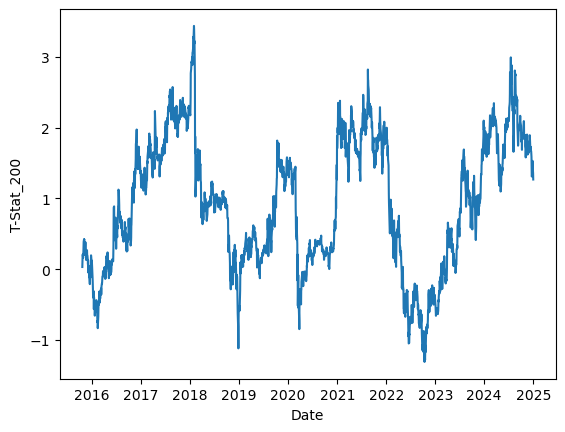

In [548]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data = df['T-Stat_200'])

<Axes: xlabel='Date', ylabel='Volatility'>

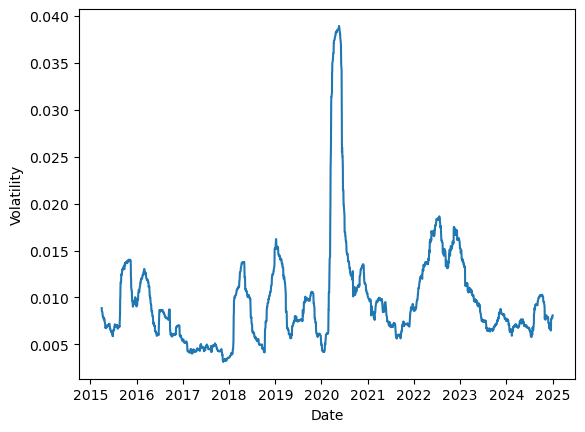

In [549]:
sns.lineplot(data = df['Volatility'])

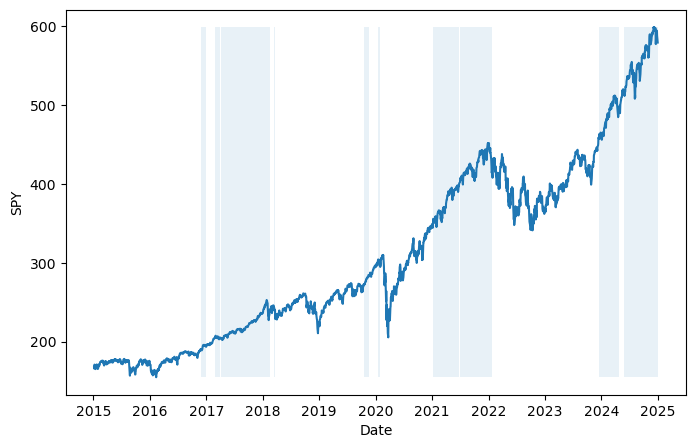

In [550]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.lineplot(data = df['SPY'], ax = ax)
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == 1), alpha = 0.1, label = 'Bull')
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == -1), alpha = 0.15, label = 'Bear')

In [551]:
df['Forward Return'] = df['Log Return'].shift(-1)
df_new = df.dropna(subset = ['Forward Return'])

bull_mean = df_new.loc[df['Regime'] == 1, 'Forward Return'].mean()
neutral_mean = df_new.loc[df['Regime'] == 0, 'Forward Return'].mean()
bear_mean = df_new.loc[df['Regime'] == -1, 'Forward Return'].mean()

print(bull_mean)
print(neutral_mean)
print(bear_mean)

df_new.loc[df_new['Regime'] == -1, 'Forward Return'].describe()

0.0006925613241662398
0.00039481034411839485
nan


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Forward Return, dtype: float64

In [552]:
df_new.groupby('Regime')['Forward Return'].std()

Regime
0.0    0.012471
1.0    0.007481
Name: Forward Return, dtype: float64

In [553]:
import numpy as np

bear_forward = df_new.loc[df_new['Regime'] == -1, 'Forward Return']

t = bear_forward.mean() / (bear_forward.std() / np.sqrt(len(bear_forward)))
print(t)

nan


In [554]:
bull_forward = df_new.loc[df_new['Regime'] == 1, 'Forward Return']

t = bull_forward.mean() / (bull_forward.std() / np.sqrt(len(bull_forward)))
print(t)

2.6136428510926164


In [555]:
neutral_forward = df_new.loc[df_new['Regime'] == 0, 'Forward Return']

t = neutral_forward.mean() / (neutral_forward.std() / np.sqrt(len(neutral_forward)))
print(t)

1.3102722095928472


In [556]:
df['Forward Vol'] = df['Volatility'].shift(-1)
df_new = df.dropna(subset =['Forward Vol'])

df_new.groupby('Vol State')['Forward Vol'].mean()

Vol State
0    0.008024
1    0.016145
Name: Forward Vol, dtype: float64

In [557]:
from regime import matrix

df = matrix.initialize_state(df)

transition_matrix = matrix.build_stationary_matrix(df)
print(transition_matrix)

Next State     0.0_0     0.0_1     1.0_0     1.0_1  nan_0
State                                                    
0.0_0       0.982933  0.010085  0.006982  0.000000   0.00
0.0_1       0.035377  0.962264  0.000000  0.002358   0.00
1.0_0       0.008535  0.000000  0.981508  0.009957   0.00
1.0_1       0.000000  0.031915  0.042553  0.925532   0.00
nan_0       0.250000  0.000000  0.000000  0.000000   0.75


In [558]:
from regime import entropy

entropy_vector = entropy.find_entropy_vector(transition_matrix)
print(entropy_vector)

State
0.0_0    0.097942
0.0_1    0.169503
1.0_0    0.104874
1.0_1    0.315901
nan_0    0.562335
dtype: float64


<Axes: xlabel='Date', ylabel='Stationary Entropy'>

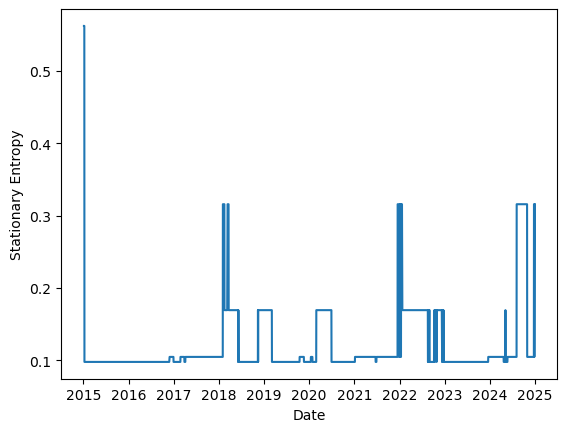

In [559]:
df = entropy.build_stationary_entropy(df, entropy_vector)

sns.lineplot(data = df['Stationary Entropy'])

<Axes: xlabel='Date', ylabel='Expanding Entropy'>

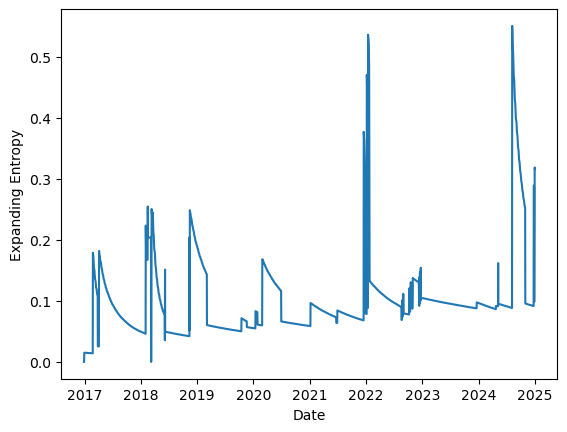

In [560]:
df = entropy.build_expanding_entropy(df)

sns.lineplot(data = df['Expanding Entropy'])

In [561]:
df['Expanding Entropy'].describe()

count    2015.000000
mean        0.100853
std         0.068392
min        -0.000000
25%         0.061692
50%         0.089423
75%         0.104732
max         0.550354
Name: Expanding Entropy, dtype: float64

In [562]:
df[[f'T-Stat_200', 'Log Return']].corr()

Ticker,T-Stat_200,Log Return
Ticker,,
T-Stat_200,1.000000,-0.016617
Log Return,-0.016617,1.000000


In [563]:
df[['Volatility', 'Log Return']].corr()

Ticker,Volatility,Log Return
Ticker,,
Volatility,1.000000,0.035205
Log Return,0.035205,1.000000


In [564]:
df[[f'T-Stat_200', 'Forward Return']].corr()

Ticker,T-Stat_200,Forward Return
Ticker,,
T-Stat_200,1.000000,-0.009882
Forward Return,-0.009882,1.000000


In [565]:
df[['Volatility', 'Forward Return']].corr()

Ticker,Volatility,Forward Return
Ticker,,
Volatility,1.000000,0.033796
Forward Return,0.033796,1.000000


In [566]:
from backtests import exposure

df = exposure.normalize_entropy(df)
df = exposure.normalize_tstat(df)
df = exposure.create_exposure(df)

In [567]:
df['Exposure'].describe()

count    2495.000000
mean        0.199543
std         0.380853
min        -0.810271
25%        -0.086916
50%         0.250900
75%         0.502208
max         0.920122
Name: Exposure, dtype: float64

In [568]:
(df['Exposure'].abs() > 0.8).mean()

0.03180914512922465

In [569]:
df['Trend'].describe()

count    2495.000000
mean        0.207691
std         0.398685
min        -0.874317
25%        -0.091423
50%         0.264246
75%         0.527568
max         0.952619
Name: Trend, dtype: float64

In [570]:
df['Confidence'].describe()

count    2515.000000
mean        0.954903
std         0.040890
min         0.692842
25%         0.945272
50%         0.956946
75%         0.973789
max         1.000000
Name: Confidence, dtype: float64

In [571]:
df['Exposure'].autocorr(lag = 1)

0.939049871935221

In [572]:
df[['Exposure', 'Log Return']].corr()

Ticker,Exposure,Log Return
Ticker,,
Exposure,1.000000,-0.019274
Log Return,-0.019274,1.000000


In [573]:
df[['Exposure', 'Forward Return']].corr()

Ticker,Exposure,Forward Return
Ticker,,
Exposure,1.000000,-0.004972
Forward Return,-0.004972,1.000000


In [574]:
df.groupby('Vol State')['Exposure'].mean()

Vol State
0    0.238242
1    0.052202
Name: Exposure, dtype: float64

In [575]:
df.groupby('Regime')['Exposure'].mean()

Regime
0.0    0.130412
1.0    0.346553
Name: Exposure, dtype: float64

In [576]:
df['Exposure Change'] = df['Exposure'].diff().abs()
df['Exposure Change'].mean()

0.09881376256025454

Text(0, 0.5, 'Exposure')

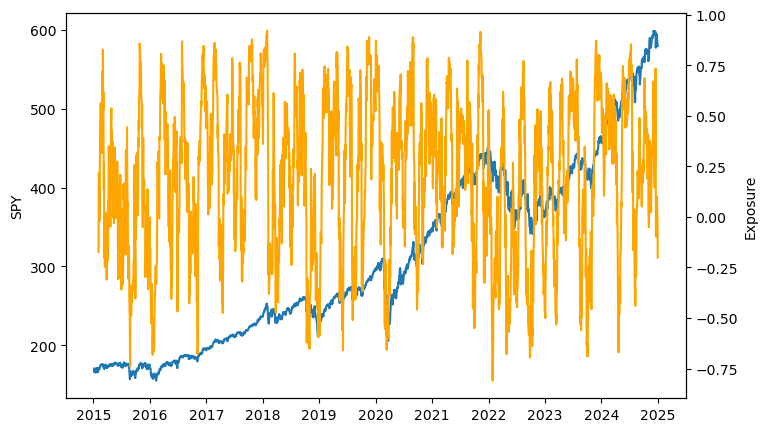

In [577]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['SPY'], label = 'SPY')
ax1.set_ylabel('SPY')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

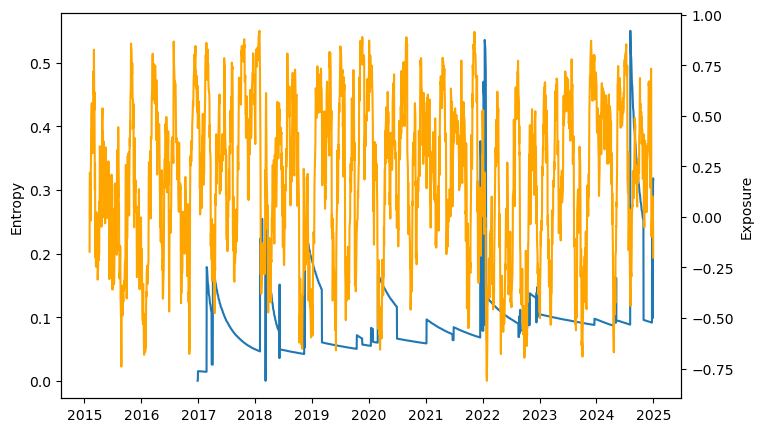

In [578]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Expanding Entropy'], label = 'Entropy')
ax1.set_ylabel('Entropy')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

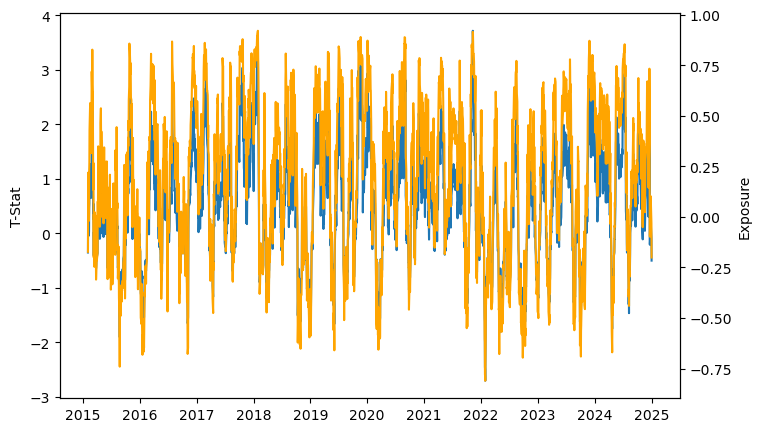

In [579]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['T-Stat_20'], label = 'T-Stat-20')
ax1.set_ylabel('T-Stat')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

<Axes: xlabel='Date'>

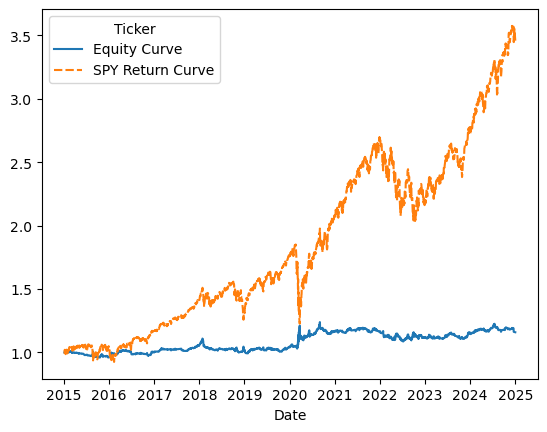

In [580]:
from backtests import backtest

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

<Axes: xlabel='Date', ylabel='Exposure'>

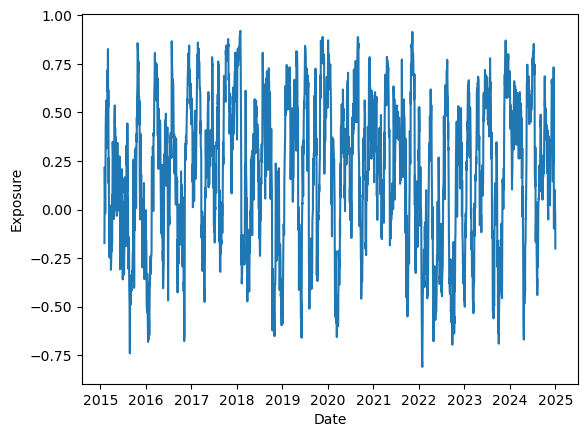

In [581]:
sns.lineplot(data = df['Exposure'])

In [582]:
(df['Exposure'] < 0).mean()

0.30854870775347915

In [583]:
df['Exposure'].corr(df['Pct Return'].shift(-1))

-0.009518381482791017

In [584]:
df['Expanding Entropy'].corr(df['Forward Vol'])

0.21676585409643837

<Axes: xlabel='Date'>

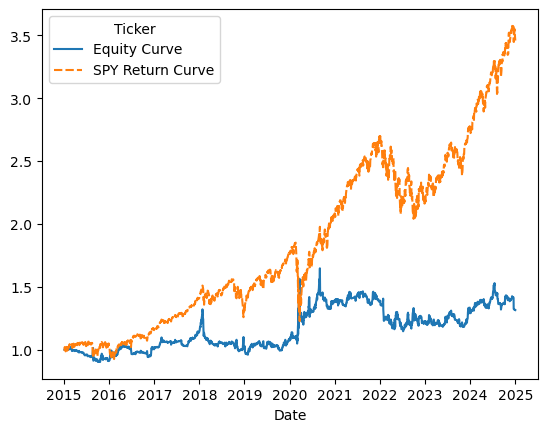

In [585]:
df['Exposure'] = df['T-Stat_20']
df['Exposure'].clip(0, 1)

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [586]:
(df['Exposure'] < 0).mean()

0.30854870775347915

<Axes: xlabel='Date'>

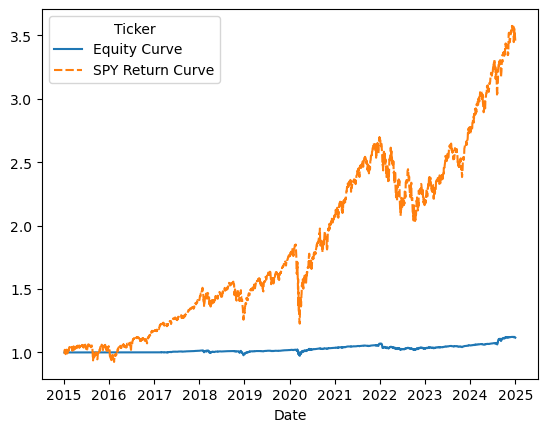

In [587]:
df['Exposure'] = df['Expanding Entropy']

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [588]:
import pandas as pd

df['Entropy Bins'] = pd.cut(df['Expanding Entropy'], bins = [0, 0.15, 0.4, 1], labels = ['Low', 'Mid', 'High'])

df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()

/var/folders/qd/xclxh05s0x9509nblm6z434w0000gp/T/ipykernel_50177/93630667.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()


,Entropy Bins,Forward Vol
0,Low,0.009654
1,Mid,0.012417
2,High,0.009051


<Axes: xlabel='Date'>

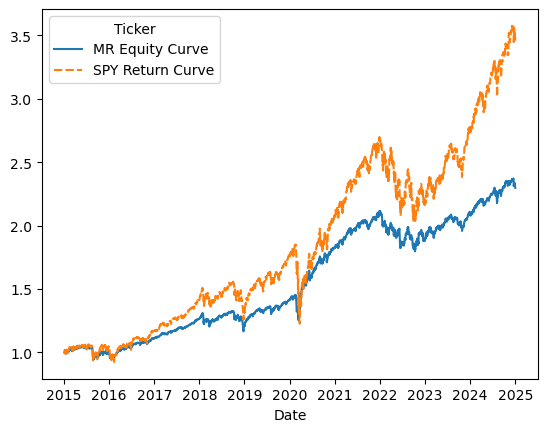

In [589]:
from backtests import mean_reversion
from features import zscore

df = zscore.calculate_zscore(df)
df = mean_reversion.generate_signal(df)
df = mean_reversion.mr_backtest(df)
sns.lineplot(data = df[['MR Equity Curve', 'SPY Return Curve']])

In [590]:
from evaluation import metrics

print(f"Mean-reversion-only Sharpe: {metrics.calculate_sharpe(df['MR Return'])}")
print(f"Mean-reversion-only max drawdown: {metrics.calculate_max_drawdown(df['MR Return'])}")

Mean-reversion-only Sharpe: 0.873748883312316
Mean-reversion-only max drawdown: -0.1500996576590524


<Axes: xlabel='Date'>

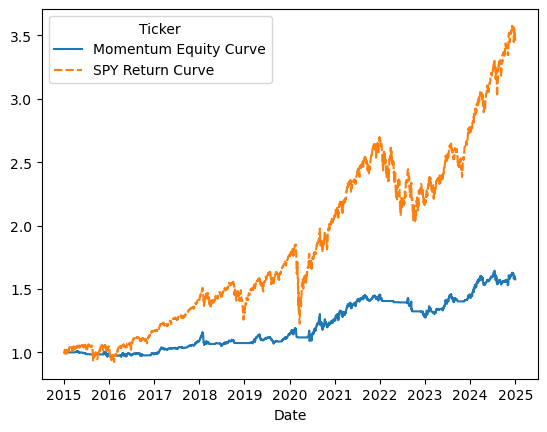

In [591]:
from backtests import momentum_backtest
from features import momentum

df = momentum.calculate_momentum(df)
df = momentum_backtest.generate_signal(df)
df = momentum_backtest.momentum_backtest(df)
sns.lineplot(data = df[['Momentum Equity Curve', 'SPY Return Curve']])

In [592]:
print(f"Momentum-only Sharpe: {metrics.calculate_sharpe(df['Momentum Return'])}")
print(f"Momentum-only max drawdown: {metrics.calculate_max_drawdown(df['Momentum Return'])}")

Momentum-only Sharpe: 0.6171083670560692
Momentum-only max drawdown: -0.12381205160822205


In [593]:
df['Momentum Signal'].describe()

count    2455.000000
mean        0.492349
std         0.382021
min         0.000000
25%         0.026515
50%         0.505692
75%         0.874064
max         1.000000
Name: Momentum Signal, dtype: float64

In [594]:
df['Momentum'].describe()

count    2455.000000
mean        0.029853
std         0.067593
min        -0.359347
25%         0.002121
50%         0.040455
75%         0.069925
max         0.334965
Name: Momentum, dtype: float64

In [595]:
print(f"SPY Sharpe: {metrics.calculate_sharpe(df['Pct Return'])}")
print(f"SPY max drawdown: {metrics.calculate_max_drawdown(df['Pct Return'])}")

SPY Sharpe: 0.7947376112669374
SPY max drawdown: -0.33717255919846245
